<a href="https://colab.research.google.com/github/YASHARTH1630/quora-duplicate-question-detection/blob/main/experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Dataset

### The dataset consists of pairs of questions along with a binary label indicating whether the two questions are semantically equivalent. Each record contains:
### question1: First question
### question2: Second question
### is_duplicate: Target label (1 = duplicate, 0 = not duplicate)

## The objective is to predict whether two questions express the same intent despite differences in wording.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("train.csv")
df.head(10)

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0
5,5,11,12,Astrology: I am a Capricorn Sun Cap moon and c...,"I'm a triple Capricorn (Sun, Moon and ascendan...",1
6,6,13,14,Should I buy tiago?,What keeps childern active and far from phone ...,0
7,7,15,16,How can I be a good geologist?,What should I do to be a great geologist?,1
8,8,17,18,When do you use シ instead of し?,"When do you use ""&"" instead of ""and""?",0
9,9,19,20,Motorola (company): Can I hack my Charter Moto...,How do I hack Motorola DCX3400 for free internet?,0


In [4]:
df.shape

(404290, 6)

## calculating weight of 0 and 1

is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

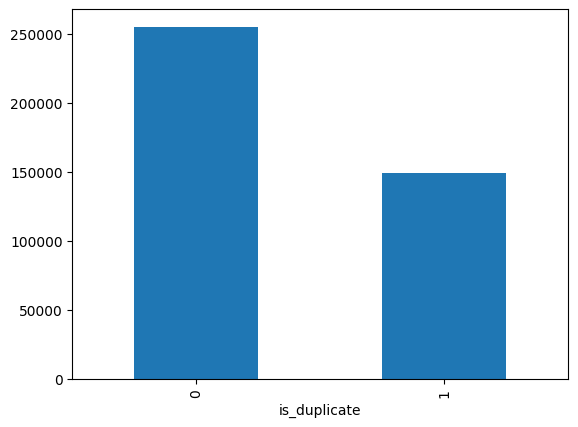

In [5]:
print(df['is_duplicate'].value_counts())
print((df['is_duplicate'].value_counts()/df['is_duplicate'].count())*100)
df['is_duplicate'].value_counts().plot(kind='bar')

In [6]:

# Repeated questions

qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print('Number of unique questions',np.unique(qid).shape[0])
x = qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number of unique questions 537933
Number of questions getting repeated 111780


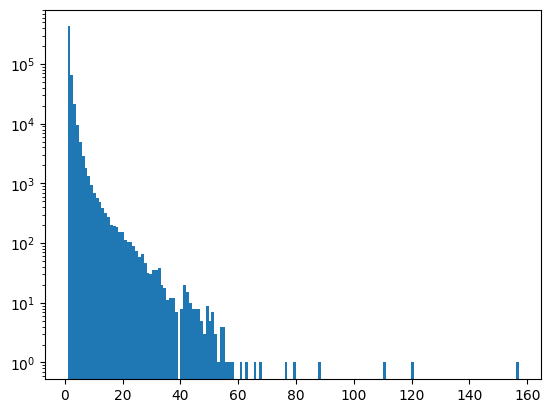

In [7]:

# Repeated questions histogram

plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

In [8]:
df.drop(columns=["id","qid1","qid2"],inplace=True)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(404290, 3)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   question1     404289 non-null  object
 1   question2     404288 non-null  object
 2   is_duplicate  404290 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 9.3+ MB


In [12]:
df.dropna(subset=['question1', 'question2'], inplace=True)

In [13]:
max_len = df['question1'].str.split().str.len().max()
print(max_len)

125


In [14]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense


# Text Preprocessing

In [15]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv("train.csv")

df = df[['question1', 'question2', 'is_duplicate']]

df.dropna(inplace=True)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['question1'] = df['question1'].apply(clean_text)
df['question2'] = df['question2'].apply(clean_text)

In [16]:
all_questions = list(df['question1']) + list(df['question2'])

### Tokenizing the word

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()

tokenizer.fit_on_texts(all_questions)

In [18]:
total_words=len(tokenizer.word_index)+1
total_words

108226

In [19]:
tokenizer.word_index

{'the': 1,
 'what': 2,
 'is': 3,
 'how': 4,
 'i': 5,
 'a': 6,
 'to': 7,
 'in': 8,
 'do': 9,
 'of': 10,
 'are': 11,
 'and': 12,
 'can': 13,
 'for': 14,
 'you': 15,
 'why': 16,
 'my': 17,
 'best': 18,
 'it': 19,
 'on': 20,
 'does': 21,
 'or': 22,
 'be': 23,
 'which': 24,
 'if': 25,
 'some': 26,
 'have': 27,
 'that': 28,
 'with': 29,
 'get': 30,
 'should': 31,
 'an': 32,
 'from': 33,
 'your': 34,
 'india': 35,
 'will': 36,
 'when': 37,
 'people': 38,
 'who': 39,
 'like': 40,
 'at': 41,
 'good': 42,
 'would': 43,
 'there': 44,
 'as': 45,
 'about': 46,
 'not': 47,
 'between': 48,
 'one': 49,
 'most': 50,
 'we': 51,
 'make': 52,
 'way': 53,
 'quora': 54,
 'did': 55,
 'where': 56,
 'by': 57,
 'any': 58,
 'me': 59,
 'was': 60,
 'so': 61,
 'life': 62,
 'after': 63,
 'this': 64,
 'they': 65,
 'money': 66,
 'time': 67,
 'know': 68,
 'difference': 69,
 'has': 70,
 'learn': 71,
 'whats': 72,
 'am': 73,
 'new': 74,
 'much': 75,
 'use': 76,
 'their': 77,
 'think': 78,
 'many': 79,
 'all': 80,
 'india

### Making the sentence from tokenized words

In [20]:
q1_seq = tokenizer.texts_to_sequences(df['question1'])

In [21]:
q2_seq = tokenizer.texts_to_sequences(df['question2'])

### Padding in the sentences to make uniform vector size of sentence

In [22]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 300

q1_pad = pad_sequences(q1_seq, maxlen=max_len)

q2_pad = pad_sequences(q2_seq, maxlen=max_len)

In [23]:
q1_pad.shape

(404287, 300)

In [24]:
y=df["is_duplicate"] ##Output

## Model Training and Initialisation

### Model Architecture
 #### A Siamese Neural Network was used for duplicate question detection. The architecture processes both questions through the same Embedding and LSTM encoder, ensuring that both inputs are mapped into the same semantic feature space using shared weights. The resulting embeddings are compared using their absolute difference, and the combined features are passed through dense layers to predict whether the questions are duplicates

In [25]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Concatenate,
    Lambda
)
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# INPUT LAYERS
input1 = Input(shape=(max_len,))
input2 = Input(shape=(max_len,))

# EMBEDDING LAYER

embedding = Embedding(
    input_dim=total_words, ##total_words analysised by tokenizer and gave them a number
    output_dim=150
)

x1 = embedding(input1)
x2 = embedding(input2)

# SHARED LSTM

shared_lstm = LSTM(150)

out1 = shared_lstm(x1)
out2 = shared_lstm(x2)

# =========================
# DIFFERENCE LAYER
# =========================
def abs_diff(x):
    return tf.abs(x[0] - x[1])

diff = Lambda(abs_diff)([out1, out2])
def mul_sim(x):
  return tf.multiply(x[0],x[1])
mul  = Lambda(mul_sim)([out1, out2]) ##similarity

merged = Concatenate()([out1, out2, diff,mul])

# DENSE LAYER
dense = Dense(
    128,
    activation='relu'
)(merged)

dense = Dropout(0.3)(dense)
# OUTPUT LAYER
output = Dense(
    1,
    activation='sigmoid'
)(dense)

# FINAL MODEL
model = Model(
    inputs=[input1, input2],
    outputs=output
)

# COMPILE
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
# SUMMARY

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 150)  │ 16,233,900 │ input_layer[0][0… │
│ (Embedding)         │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 150)       │    180,600 │ embedding[0][0],  │
│                     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 150)       │          0 │ lstm[0][0],       │
│                     │                   │            │ lstm[1][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 150)       │          0 │ lstm[0][0],       │
│                     │                   │            │ lstm[1][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 600)       │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ lstm[1][0],       │
│                     │                   │            │ lambda[0][0],     │
│                     │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     76,928 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,491,557 (62.91 MB)

 Trainable params: 16,491,557 (62.91 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
## Early Stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3)

In [27]:
## Train the model over training data
model.fit(
    [q1_pad, q2_pad],
    y,
    epochs=6,
    batch_size=32,
    callbacks=[early_stopping],
    validation_split=0.2
)

Epoch 1/6
10108/10108 ━━━━━━━━━━━━━━━━━━━━ 400s 39ms/step - accuracy: 0.7957 - loss: 0.4345 - val_accuracy: 0.8334 - val_loss: 0.3693
Epoch 2/6
10108/10108 ━━━━━━━━━━━━━━━━━━━━ 393s 39ms/step - accuracy: 0.8744 - loss: 0.2898 - val_accuracy: 0.8467 - val_loss: 0.3483
Epoch 3/6
10108/10108 ━━━━━━━━━━━━━━━━━━━━ 395s 39ms/step - accuracy: 0.9178 - loss: 0.1987 - val_accuracy: 0.8491 - val_loss: 0.3749
Epoch 4/6
10108/10108 ━━━━━━━━━━━━━━━━━━━━ 393s 39ms/step - accuracy: 0.9448 - loss: 0.1375 - val_accuracy: 0.8461 - val_loss: 0.4345
Epoch 5/6
10108/10108 ━━━━━━━━━━━━━━━━━━━━ 393s 39ms/step - accuracy: 0.9612 - loss: 0.0981 - val_accuracy: 0.8547 - val_loss: 0.4946


## Validation Accuracy is 85.4%

In [28]:
## Save the model for prediction
model.save("similiar.h5")

In [29]:
import pickle

with open("tokenizer1.pkl", "wb") as f:
    pickle.dump(tokenizer, f)